In [1]:
import pandas as pd
from sqlalchemy import create_engine
import os
import json
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.manifold import TSNE
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

In [2]:
def load_credentials(path = "aws_rds_credentials.json"):
     with open(path, 'r') as file:
          config = json.load(file)

     # set up credentials
     for key in config.keys():
          os.environ[key] = config[key]

     return


load_credentials()

aws_rds_url = f"postgresql://{os.environ['user']}:{os.environ['password']}@{os.environ['host']}:{os.environ['port']}/{os.environ['database']}?sslmode=require"

# Load a sample dataset
def load_data():
    engine = create_engine(aws_rds_url)
    sql_query = """
        SELECT t1.user_id, 
            COUNT(DISTINCT(t1.product_id)) as count_products, 
            SUM(t1.price_numeric) as sum_price, 
            AVG(t1.price_numeric) as avg_price, 
            AVG(t1.package_size_id) as avg_package_size, 
            SUM(t1.view_count) as total_views,
            AVG(t1.view_count) as avg_views,
            SUM(t1.favourite_count) as total_favourite,
            AVG(t1.favourite_count) as avg_favourite
        FROM public.tracking_staging  t1
        JOIN (
            SELECT product_id, MAX(date) AS latest_date
            FROM public.tracking_staging 
            GROUP BY product_id
        ) t2 ON t1.product_id = t2.product_id AND t1.date = t2.latest_date
        GROUP BY user_id
    """
    #sql_query = "select * from public.tracking_staging limit 100"
    df = pd.read_sql(sql_query, engine)
    return (df)

data = load_data()
print(f"The dataframe has {len(data)} columns")
data.head(5)

The dataframe has 1490 columns


,user_id,count_products,sum_price,avg_price,avg_package_size,total_views,avg_views,total_favourite,avg_favourite
0,126937.0,34,118,3.470588,1.000000,548,16.117647,88,2.588235
1,184881.0,15,153,10.200000,1.000000,618,41.200000,111,7.400000
2,278357.0,55,1155,21.000000,2.127273,2920,53.090909,376,6.836364
3,284071.0,18,285,15.833333,1.500000,1359,75.500000,109,6.055556
4,458357.0,80,456,5.700000,1.187500,1655,20.687500,115,1.437500


In [3]:
data = data.dropna()
print(f"The dataframe has {len(data)} columns")

The dataframe has 1489 columns


In [4]:
fig = go.Figure()

cols = ["count_products", "sum_price", "avg_price", "avg_package_size", "total_views", "total_favourite", "avg_views", "avg_favourite"]

for col in cols:
    fig.add_trace(go.Violin(y=data[col],
                            name=col,
                            box_visible=True,
                            meanline_visible=True))
    
fig

In [5]:
data.skew()

user_id              0.569103
count_products       5.386971
sum_price            5.817207
avg_price            5.311424
avg_package_size     1.157645
total_views          4.682495
avg_views            3.547965
total_favourite     12.548036
avg_favourite        6.724063
dtype: float64

In [6]:
data.drop("user_id", axis = 1).describe()

,count_products,sum_price,avg_price,avg_package_size,total_views,avg_views,total_favourite,avg_favourite
count,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000,1489.000000
mean,50.963734,907.793150,26.351099,1.514225,1685.875756,43.635951,213.728677,4.065822
std,71.024019,1692.510099,40.141509,0.467859,2656.083857,49.398229,773.699235,6.206755
min,1.000000,3.000000,1.187500,1.000000,0.000000,0.000000,0.000000,0.000000
25%,13.000000,195.000000,6.876712,1.131250,395.000000,16.195652,32.000000,1.352113
50%,35.000000,411.000000,13.685714,1.400000,914.000000,28.410714,76.000000,2.363636
75%,59.000000,900.000000,27.891720,1.795455,1884.000000,51.066667,165.000000,4.500000
max,1000.000000,25274.000000,586.407407,3.250000,25155.000000,503.555556,16193.000000,98.111111


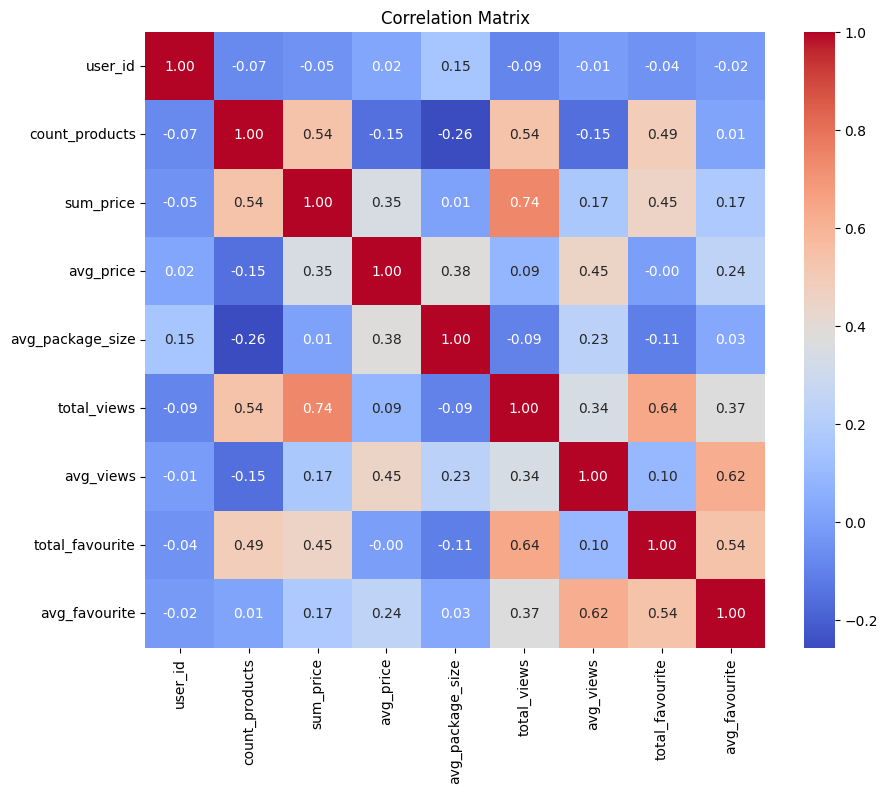

In [7]:
corr_matrix = data.corr()

# Plotting the correlation matrix using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [8]:
"""
# Select columns to remove outliers from
columns_to_remove_outliers = ["sum_price", "total_views", "total_favourite", "avg_price", "avg_favourite", "count_products"]

# Compute Z-score for selected columns
scaler = StandardScaler()
df_zscore = data.copy()
df_zscore[columns_to_remove_outliers] = scaler.fit_transform(df_zscore[columns_to_remove_outliers])

# Define threshold for Z-score
threshold = 3

# Filter out rows with Z-score greater than threshold
df_filtered = df_zscore[(np.abs(df_zscore[columns_to_remove_outliers]) < threshold).all(axis=1)]

# Convert back to original scale
df_filtered[columns_to_remove_outliers] = scaler.inverse_transform(df_filtered[columns_to_remove_outliers])
data = df_filtered
data.head(5)
"""


'\n# Select columns to remove outliers from\ncolumns_to_remove_outliers = ["sum_price", "total_views", "total_favourite", "avg_price", "avg_favourite", "count_products"]\n\n# Compute Z-score for selected columns\nscaler = StandardScaler()\ndf_zscore = data.copy()\ndf_zscore[columns_to_remove_outliers] = scaler.fit_transform(df_zscore[columns_to_remove_outliers])\n\n# Define threshold for Z-score\nthreshold = 3\n\n# Filter out rows with Z-score greater than threshold\ndf_filtered = df_zscore[(np.abs(df_zscore[columns_to_remove_outliers]) < threshold).all(axis=1)]\n\n# Convert back to original scale\ndf_filtered[columns_to_remove_outliers] = scaler.inverse_transform(df_filtered[columns_to_remove_outliers])\ndata = df_filtered\ndata.head(5)\n'

In [9]:
for col in data.columns:
    data[col] = MinMaxScaler().fit_transform(X = data[[col]])
data.head(5)

,user_id,count_products,sum_price,avg_price,avg_package_size,total_views,avg_views,total_favourite,avg_favourite
0,0.000000,0.033033,0.004551,0.003901,0.000000,0.021785,0.032008,0.005434,0.026381
1,0.000285,0.014014,0.005936,0.015400,0.000000,0.024568,0.081818,0.006855,0.075425
2,0.000744,0.054054,0.045586,0.033855,0.501010,0.116080,0.105432,0.023220,0.069680
3,0.000772,0.017017,0.011159,0.025026,0.222222,0.054025,0.149934,0.006731,0.061721
4,0.001628,0.079079,0.017926,0.007711,0.083333,0.065792,0.041083,0.007102,0.014652


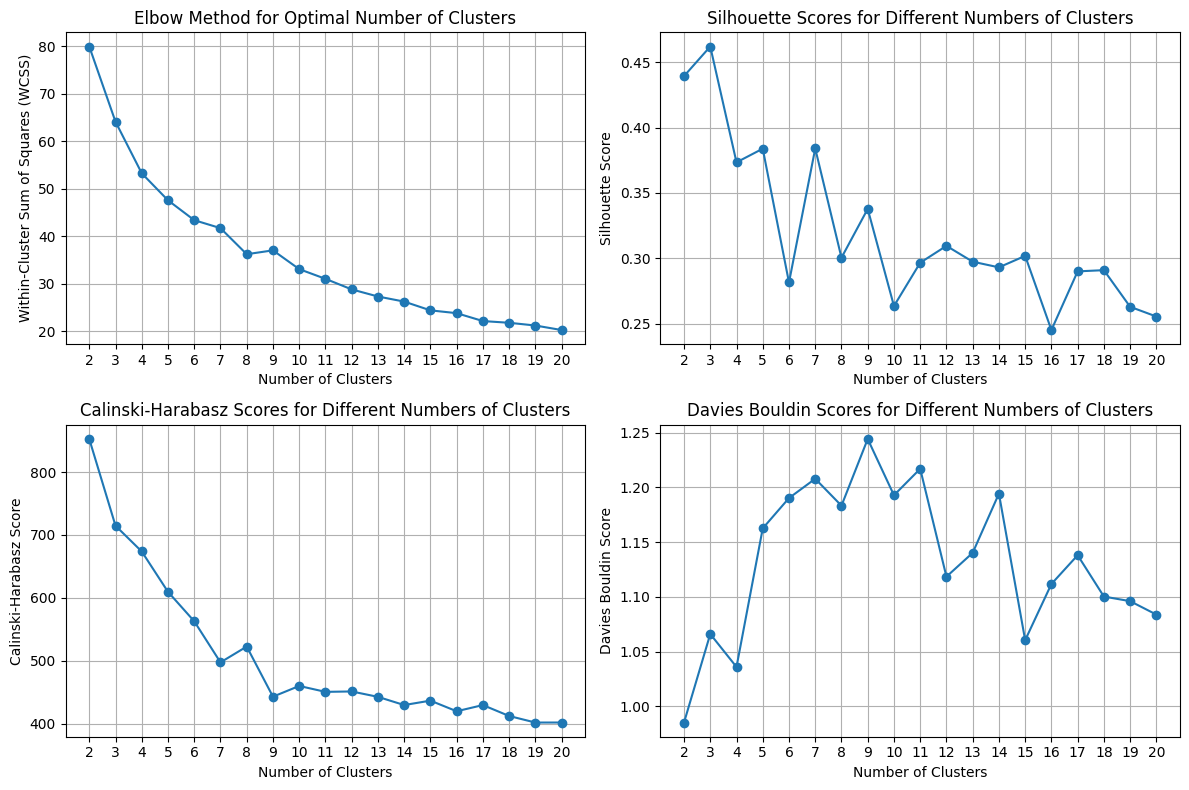

In [10]:
k_range = range(2, 21)

# Initialize lists to store evaluation metrics
wcss = []
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []

# Loop over the range of clusters
for k in k_range:
    # Initialize KMeans object
    kmeans = KMeans(n_clusters=k,
                    algorithm= "elkan",
                    max_iter= 500)
    # Fit KMeans to the data
    kmeans.fit(data.drop(["user_id"], axis=1))
    # Append the value of WCSS to the list
    wcss.append(kmeans.inertia_)
    # Compute silhouette score
    silhouette_avg = silhouette_score(data.drop(["user_id"], axis=1), kmeans.labels_)
    silhouette_scores.append(silhouette_avg)
    # Compute Calinski-Harabasz score
    calinski_score = calinski_harabasz_score(data.drop(["user_id"], axis=1), kmeans.labels_)
    calinski_scores.append(calinski_score)
    # Compute Calinski-Harabasz score
    davies_bouldin = davies_bouldin_score(data.drop(["user_id"], axis=1), kmeans.labels_)
    davies_bouldin_scores.append(davies_bouldin)

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# Plot the elbow curve
axes[0, 0].plot(k_range, wcss, marker='o', linestyle='-')
axes[0, 0].set_title('Elbow Method for Optimal Number of Clusters')
axes[0, 0].set_xlabel('Number of Clusters')
axes[0, 0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0, 0].set_xticks(k_range)
axes[0, 0].grid(True)

# Plot silhouette scores
axes[0, 1].plot(k_range, silhouette_scores, marker='o', linestyle='-')
axes[0, 1].set_title('Silhouette Scores for Different Numbers of Clusters')
axes[0, 1].set_xlabel('Number of Clusters')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].set_xticks(k_range)
axes[0, 1].grid(True)

# Plot Calinski-Harabasz scores
axes[1, 0].plot(k_range, calinski_scores, marker='o', linestyle='-')
axes[1, 0].set_title('Calinski-Harabasz Scores for Different Numbers of Clusters')
axes[1, 0].set_xlabel('Number of Clusters')
axes[1, 0].set_ylabel('Calinski-Harabasz Score')
axes[1, 0].set_xticks(k_range)
axes[1, 0].grid(True)

# Plot Calinski-Harabasz scores
axes[1, 1].plot(k_range, davies_bouldin_scores, marker='o', linestyle='-')
axes[1, 1].set_title('Davies Bouldin Scores for Different Numbers of Clusters')
axes[1, 1].set_xlabel('Number of Clusters')
axes[1, 1].set_ylabel('Davies Bouldin Score')
axes[1, 1].set_xticks(k_range)
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [11]:
kmeans = KMeans(n_clusters=5,
                algorithm= "elkan",
                max_iter= 500)
kmeans.fit(data.drop(["user_id"], axis= 1))
data["labels"] = kmeans.labels_
data.head(5)

,user_id,count_products,sum_price,avg_price,avg_package_size,total_views,avg_views,total_favourite,avg_favourite,labels
0,0.000000,0.033033,0.004551,0.003901,0.000000,0.021785,0.032008,0.005434,0.026381,2
1,0.000285,0.014014,0.005936,0.015400,0.000000,0.024568,0.081818,0.006855,0.075425,2
2,0.000744,0.054054,0.045586,0.033855,0.501010,0.116080,0.105432,0.023220,0.069680,0
3,0.000772,0.017017,0.011159,0.025026,0.222222,0.054025,0.149934,0.006731,0.061721,0
4,0.001628,0.079079,0.017926,0.007711,0.083333,0.065792,0.041083,0.007102,0.014652,2


In [12]:
# Compute t-SNE embeddings
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
X_tsne = tsne.fit_transform(data.drop(["user_id", "labels"], axis = 1))

pca_df = pd.DataFrame(data=X_tsne, 
                      columns=['PC1', 'PC2'], 
                      index = data.index)

concat_df = pd.concat([pca_df, 
                       data], 
                      ignore_index= False, 
                      axis=1)

concat_df = concat_df.rename(columns={0: 'Cluster'})
concat_df.index = concat_df.index.astype("category")
print(concat_df.index.dtype)

fig = px.scatter(concat_df, x='PC1', y='PC2', color='labels', title='t-SNE Plot')
fig

category


In [13]:
# Calculate the percentages
df_style = data.groupby("labels")["user_id"].count() / data.groupby("labels")["user_id"].count().sum()

# Function to format values as percentages with 2 decimals
def format_percentage(value):
    return '{:.2%}'.format(value)

# Apply formatting function and styling
styled_data = df_style.reset_index(name="count").apply(lambda x: format_percentage(x['count']), axis=1).reset_index(drop=True).to_frame()
styled_data.columns = ['count']
styled_data.style.set_caption('Percentage of User IDs by Cluster label')
styled_data

,count
0,31.97%
1,8.53%
2,53.53%
3,2.48%
4,3.49%


In [14]:
# Aggregate mean values for each label across different features
radar_data = []
for label in data["labels"].unique():
    label_data = data[data["labels"] == label].drop(["user_id", "labels"], axis=1).mean() * 100
    radar_data.append(label_data)

# Define feature names
feature_names = radar_data[0].index.tolist()

# Create traces for radar chart
traces = []
for i, label_data in enumerate(radar_data):
    trace = go.Scatterpolar(
        r=label_data.values,
        theta=feature_names,
        fill='toself',
        name=f'Label {i}'
    )
    traces.append(trace)

# Define layout
layout = go.Layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 100]  # Adjust the range as needed
        )
    ),
    showlegend=True
)

# Create figure
fig = go.Figure(data=traces, layout=layout)

# Show plot
fig.show()

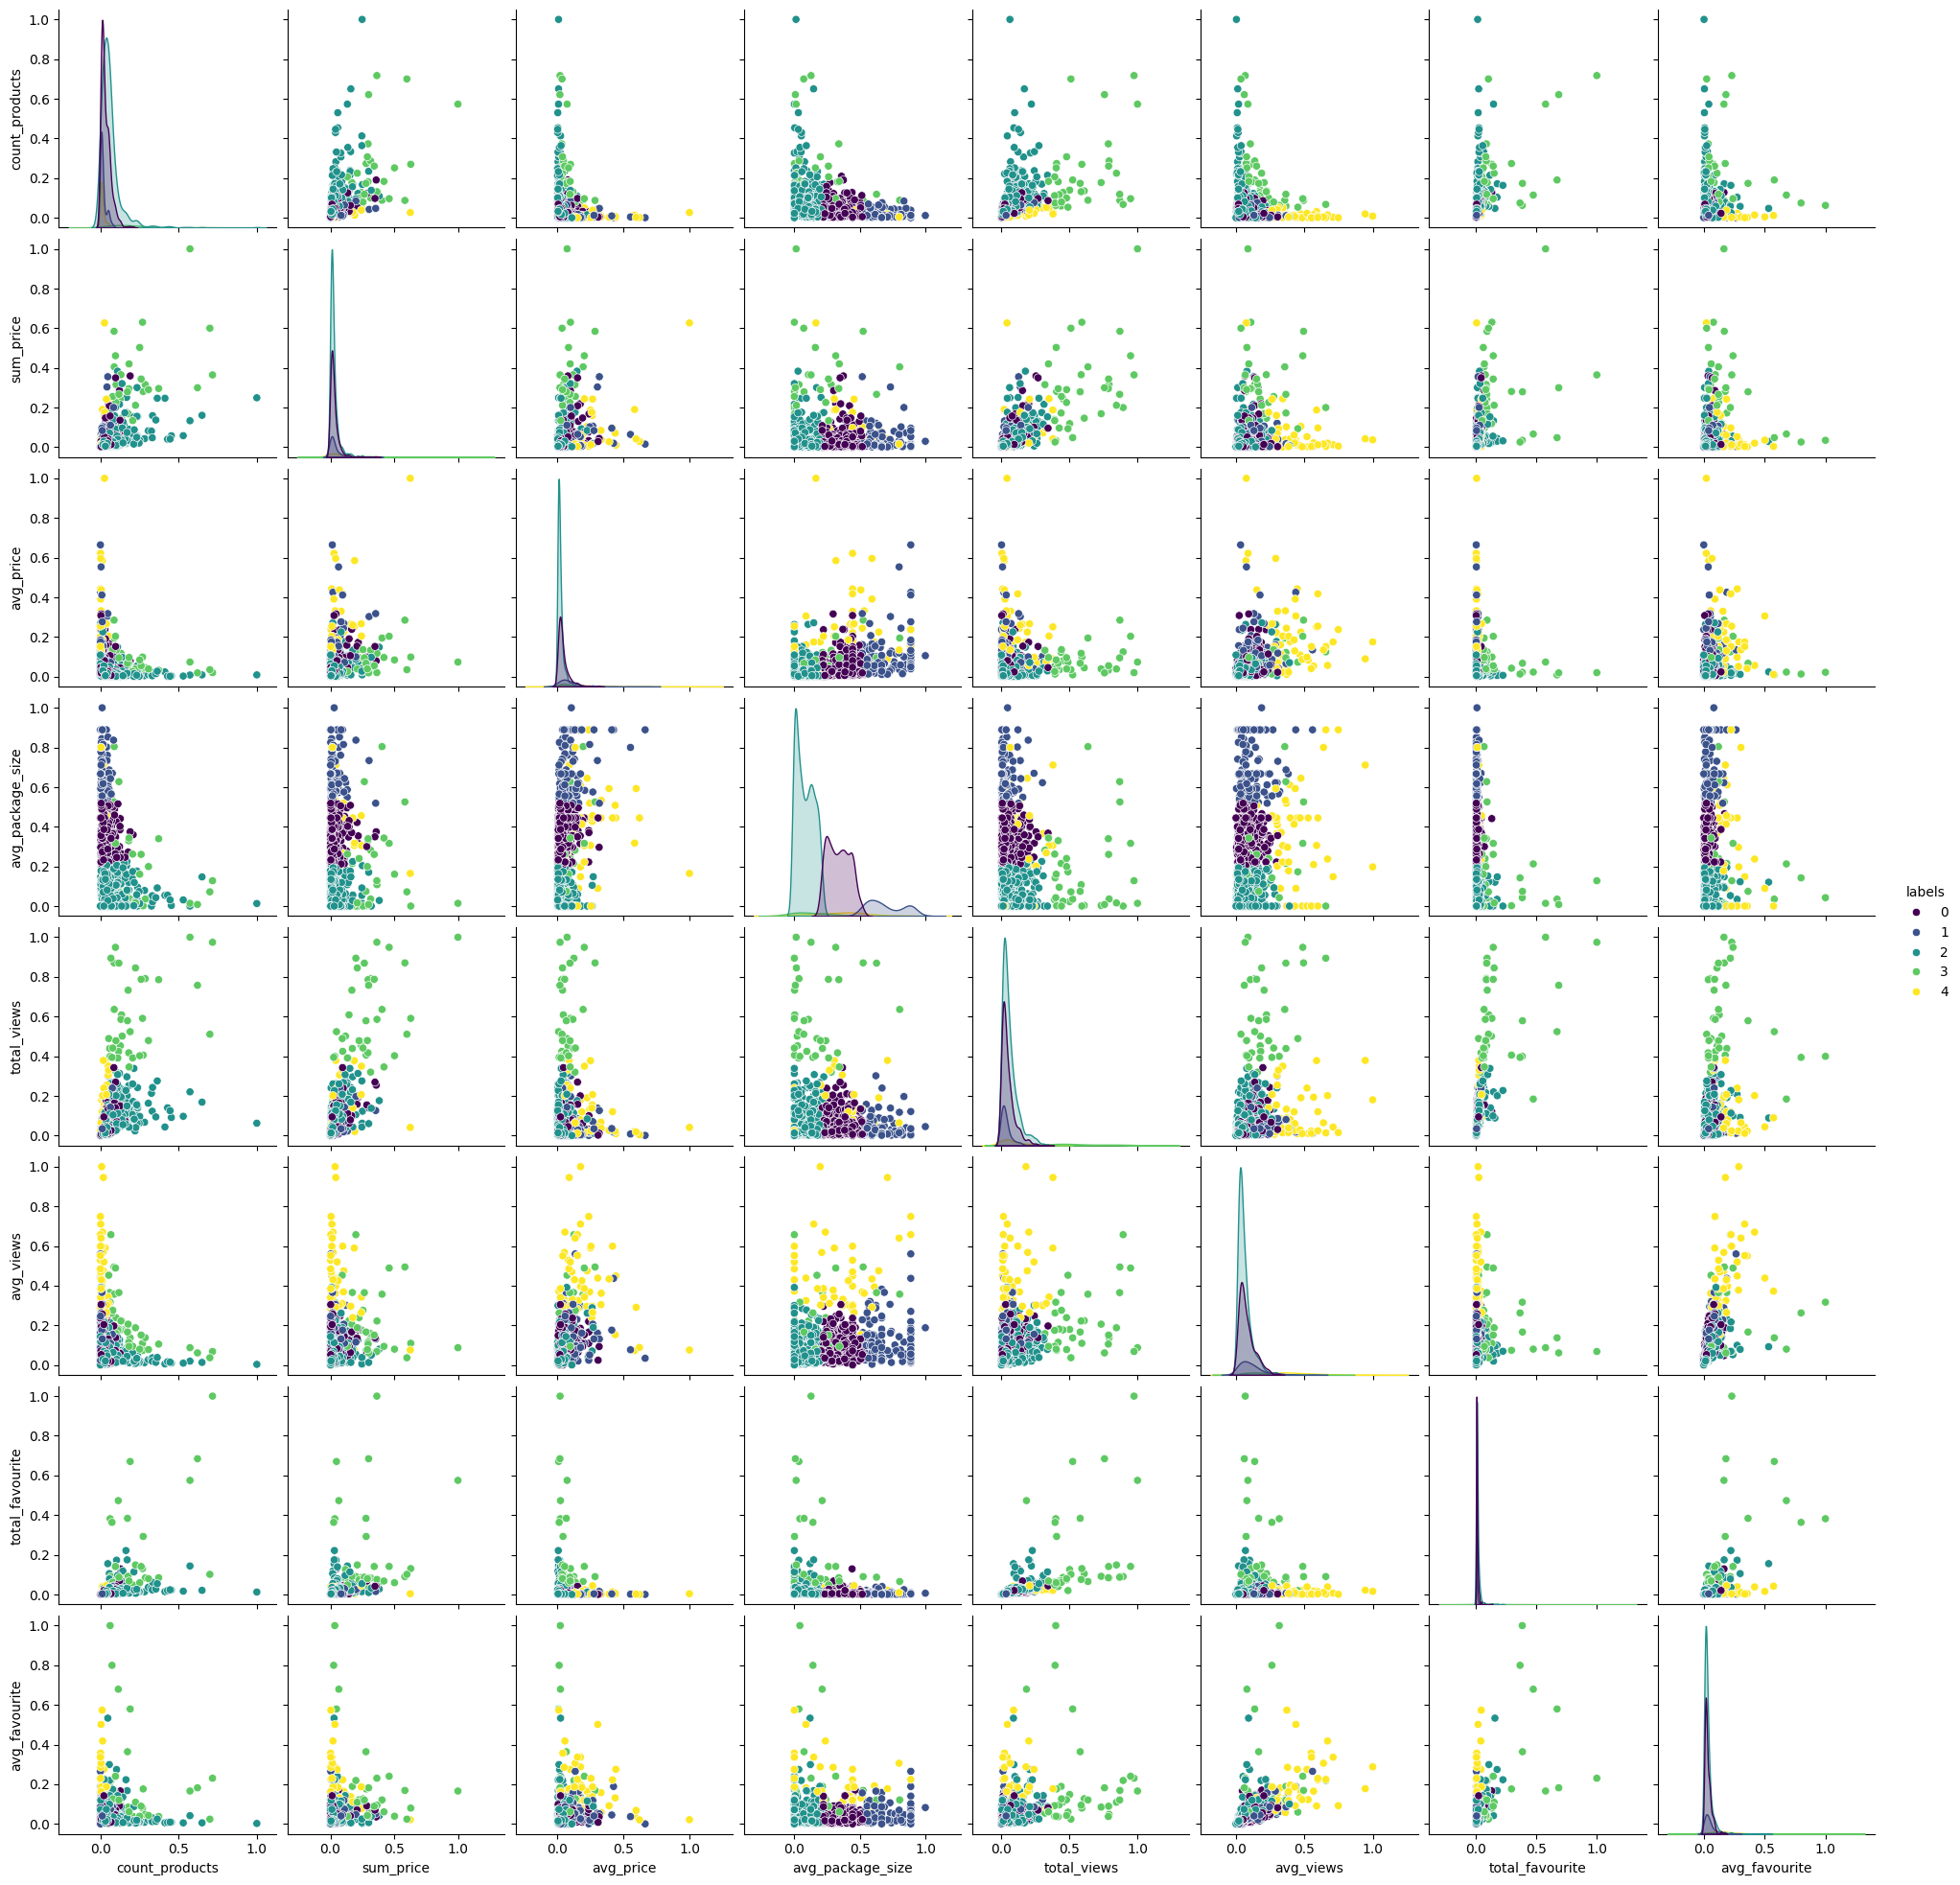

In [15]:
columns = ['count_products', 'sum_price', 'avg_price', 
           'avg_package_size', 
           'total_views', 'avg_views', 'total_favourite', 'avg_favourite', 
           'labels']

# Create a pairplot
sns.pairplot(data[columns], hue='labels', palette='viridis')